### Strain extraction and processing

This notebook extracts strain data, computes the average of the absolute value of the strain for each channel and for each event.
For each event, 6 average values are saved for span 1 and 6 for span 2.
Then for each event, the ratio between the sum of the first 6 values (span 1) and the sum of the other 6 values (span 2) are computed. IN this way, we obtain a quantity that should be almost constant.
If environmental effects affect both spans in the same way, then they are removed.

I used my own directory, please change to yours/main EWSHM 





In [1]:
import os
os.chdir(r"C:\Users\tomma\EWSHM_Competition")

C:\Users\tomma


In [4]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from aquinas_toolkit import AquinasReader
from aquinas_toolkit.preprocessing import (
    align_event_group,
    bandpass_filter_waveform_matrix,
    export_aligned_event,
    filter_loaded_event_group,
    find_common_sensor_events,
    find_events,
    load_common_event_waveform_matrix,
    load_event_group,
    summarize_min_duration_filter,
    zero_loaded_event_group,
)

In [6]:
# ---------------------------------------------------------------------------
# Dataset and filter constants
# ---------------------------------------------------------------------------
#DATASET_ROOT = Path("..") / "AQUINAS_DATASET"
DATASET_ROOT = Path(r"C:\Users\tomma\EWSHM_Competition\AQUINAS_DATASET")

SAMPLE_RATE_HZ = 100.0
LOW_HZ = 0.5
HIGH_HZ = 20.0
MIN_DURATION_SECONDS = 10.0
EXAMPLE_DECK = "OLD"

# Reader for SET1 (used for acceleration examples)
set1_dir = DATASET_ROOT / "AQUINAS_SET1_2022_07"
reader = AquinasReader(set1_dir)

# Two organizer-shared timestamps used as running examples throughout this notebook
shared_timestamps = [
    "2022-07-02 03:34:40",   # SET1 OLD STR event
    "2022-07-30 18:36:53",   # SET1 OLD ACC_Z event
]

This cell prints the time history of events. Sometimes the events are misaligned (e.g., instead of printing 12 sensors in a plot, 10 + 2 in different plots are printed due to slightly different time length of recordings). You can see a first bunch of peaks associated to vehicle passing on span 1 and then a second bunch of peaks associated to span 2

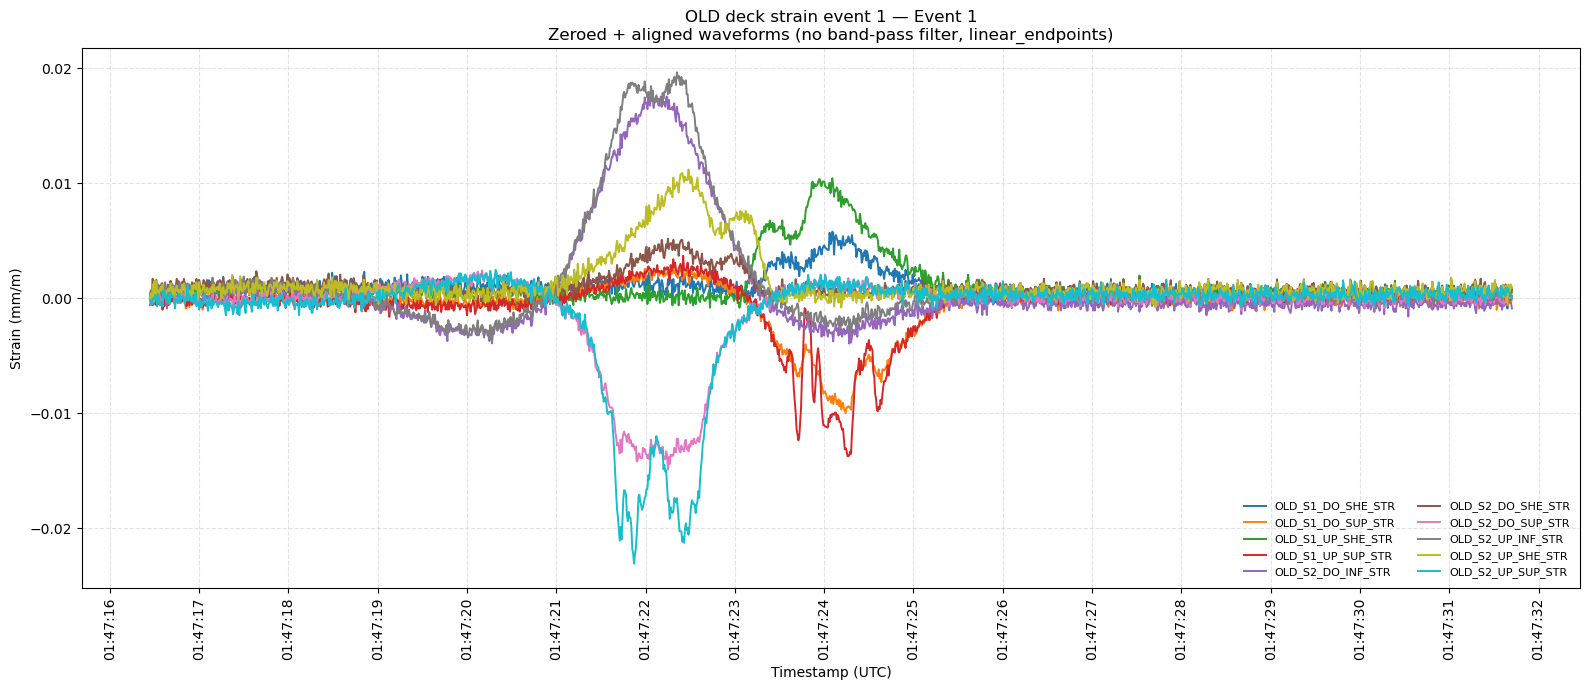

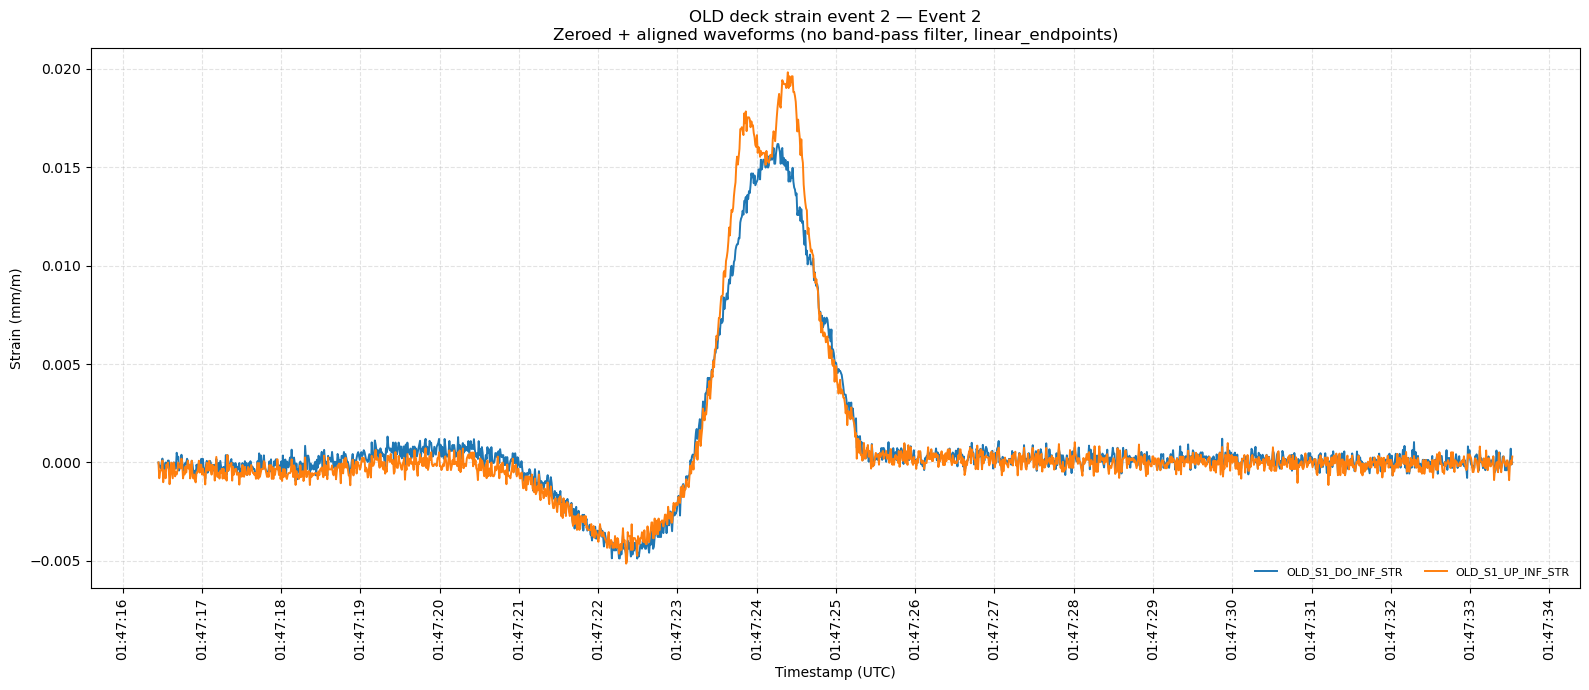

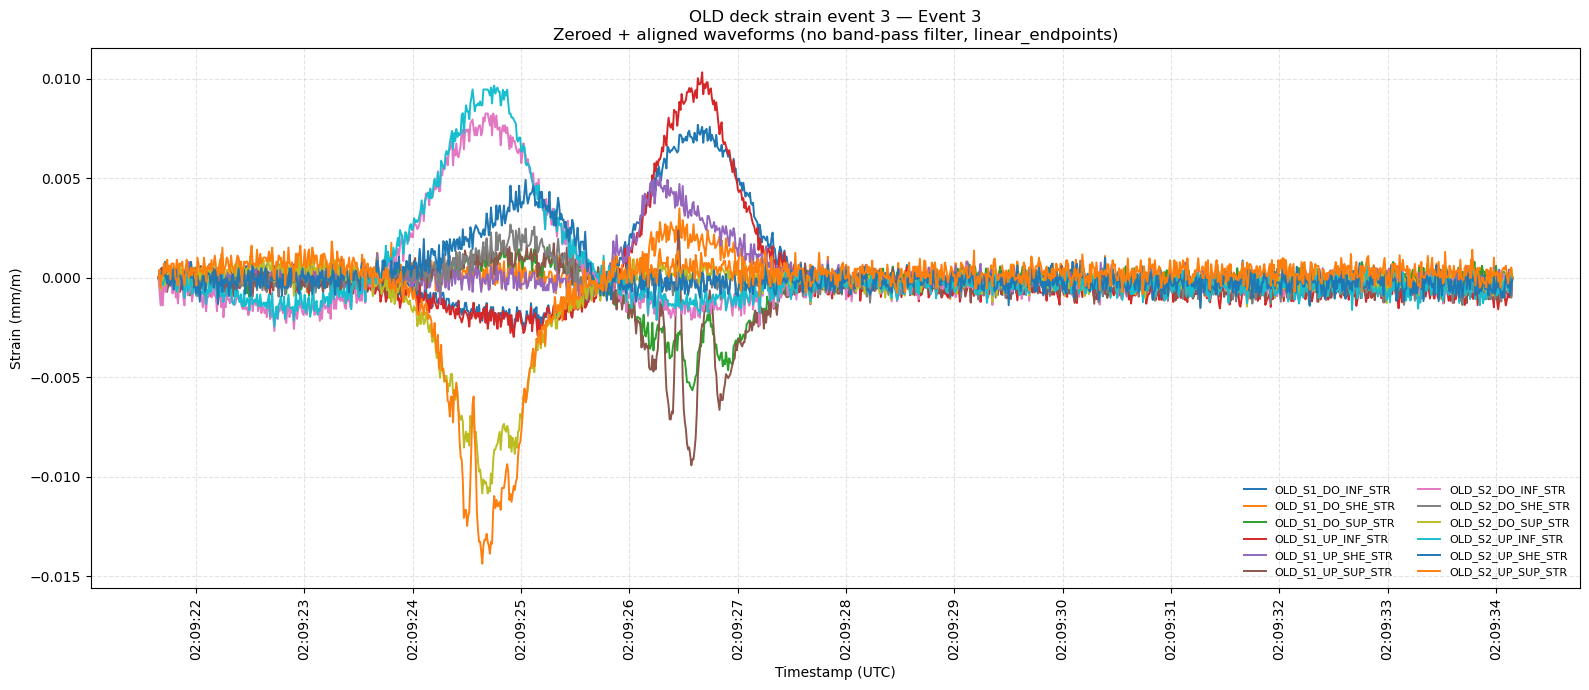

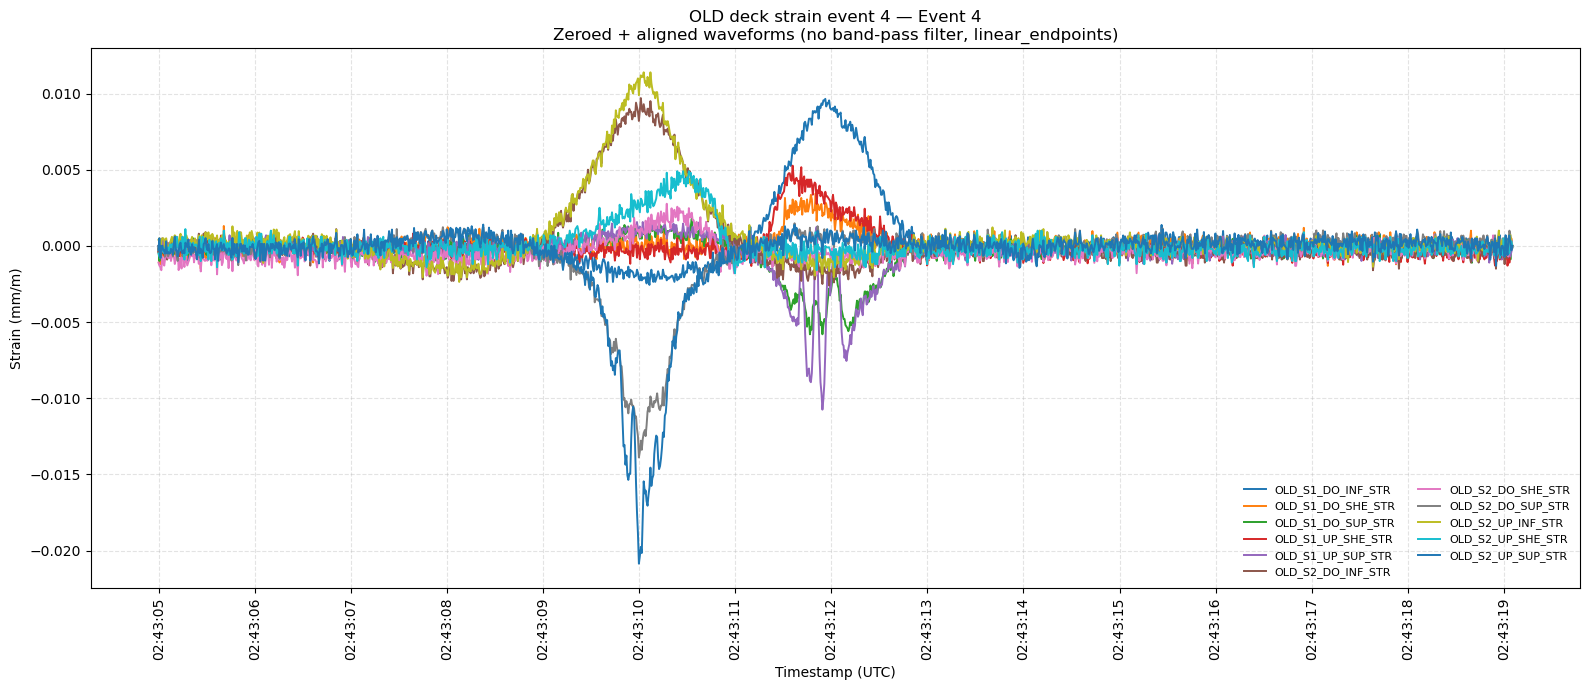

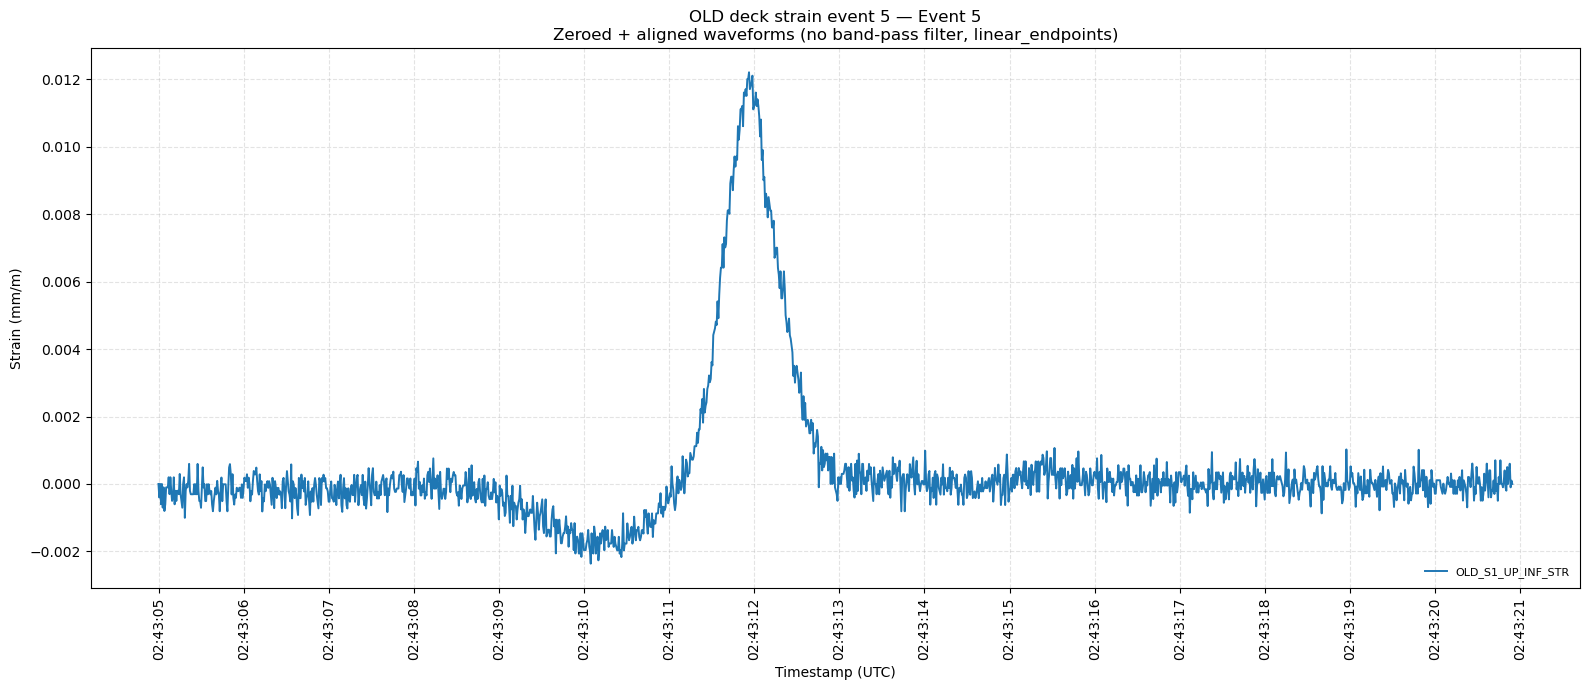

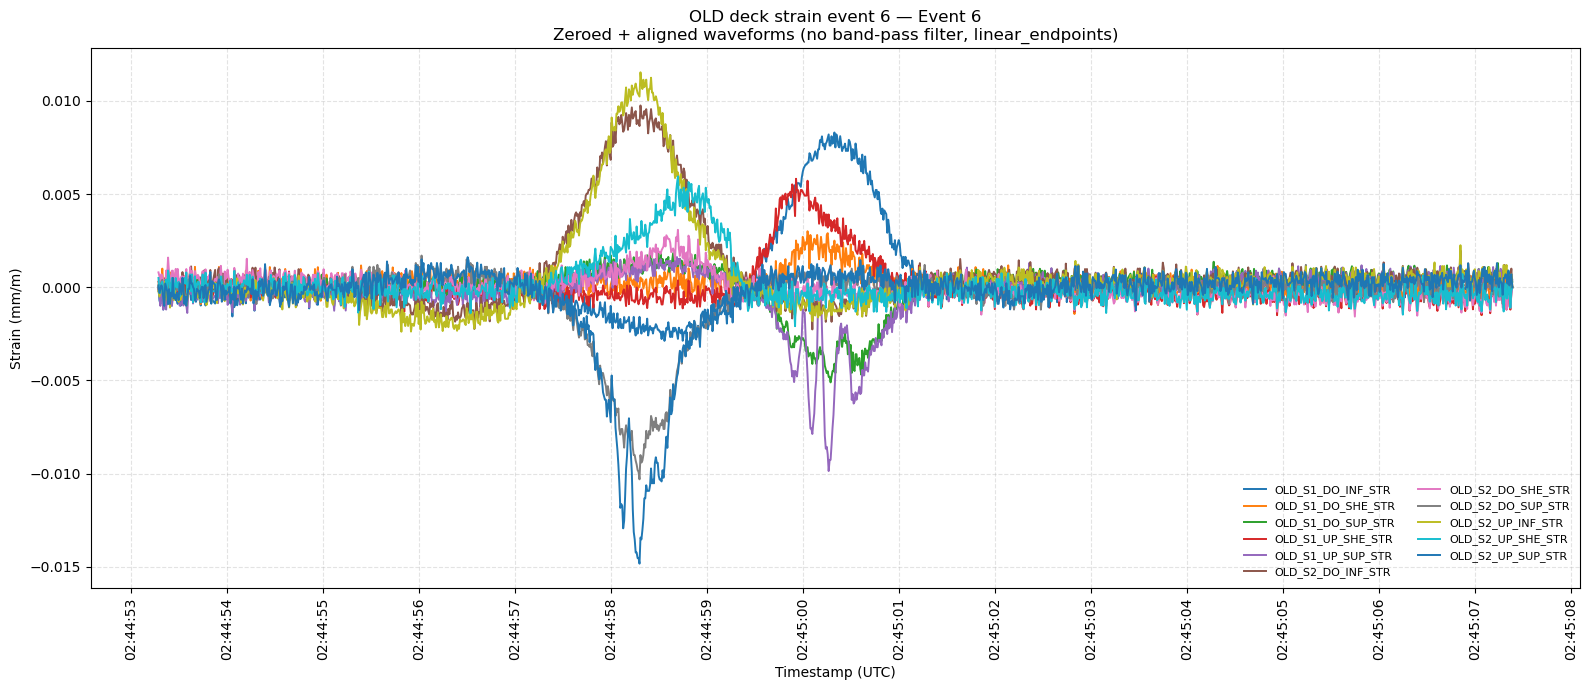

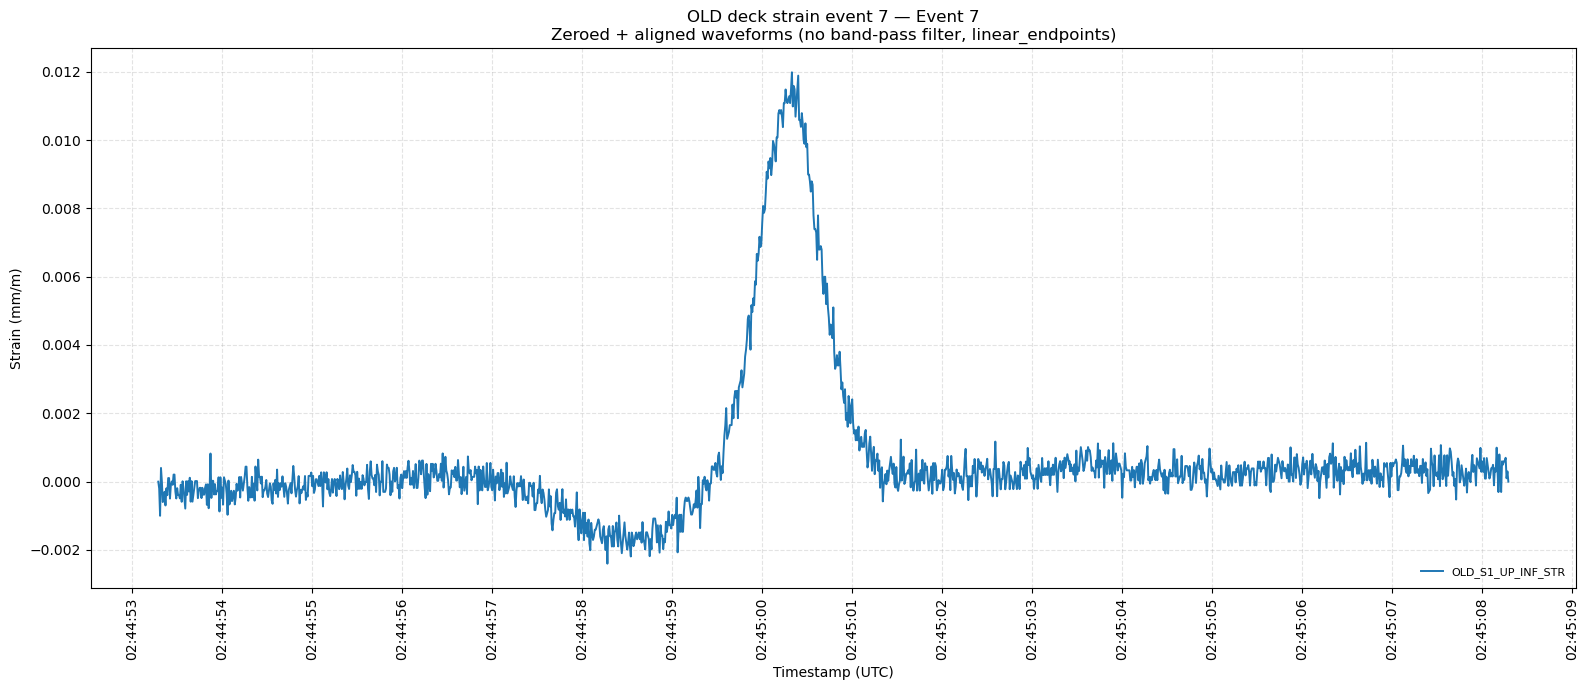

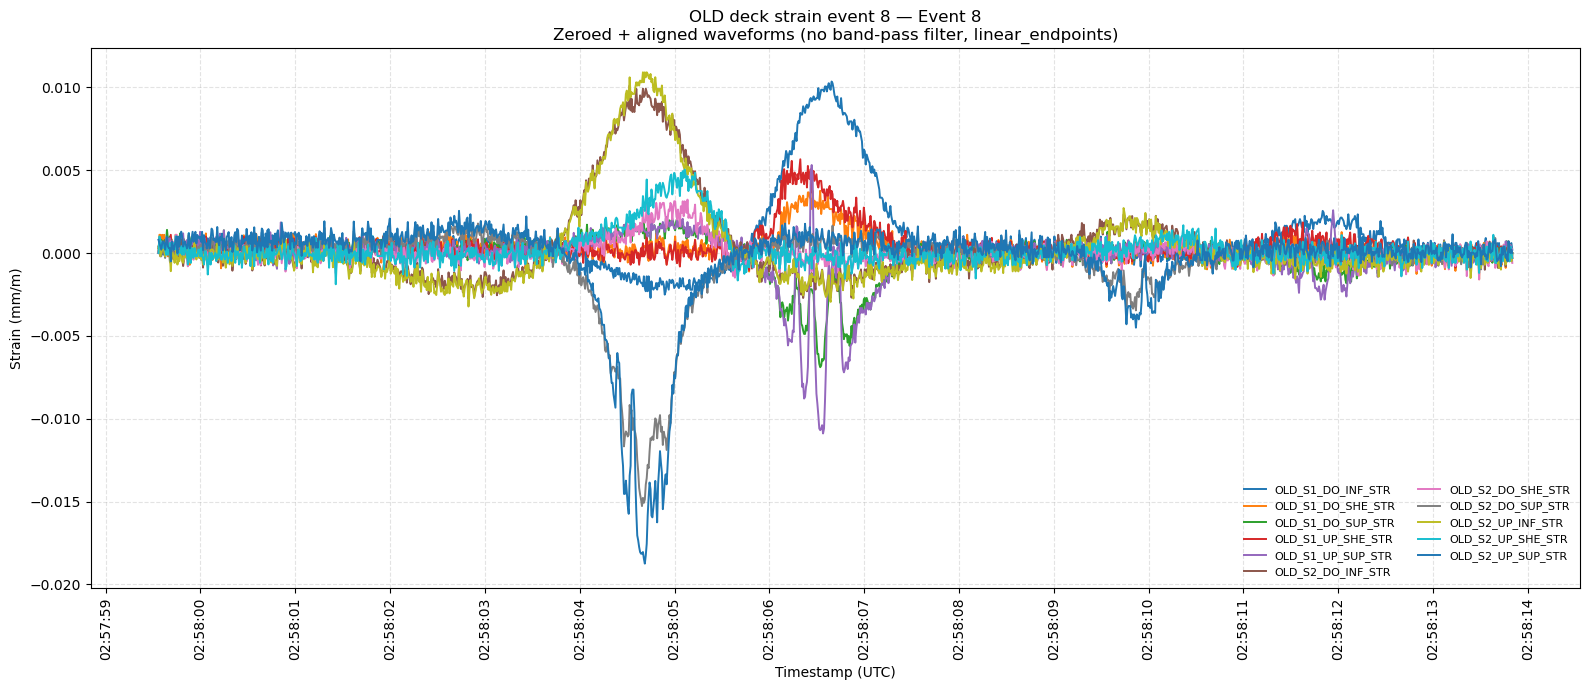

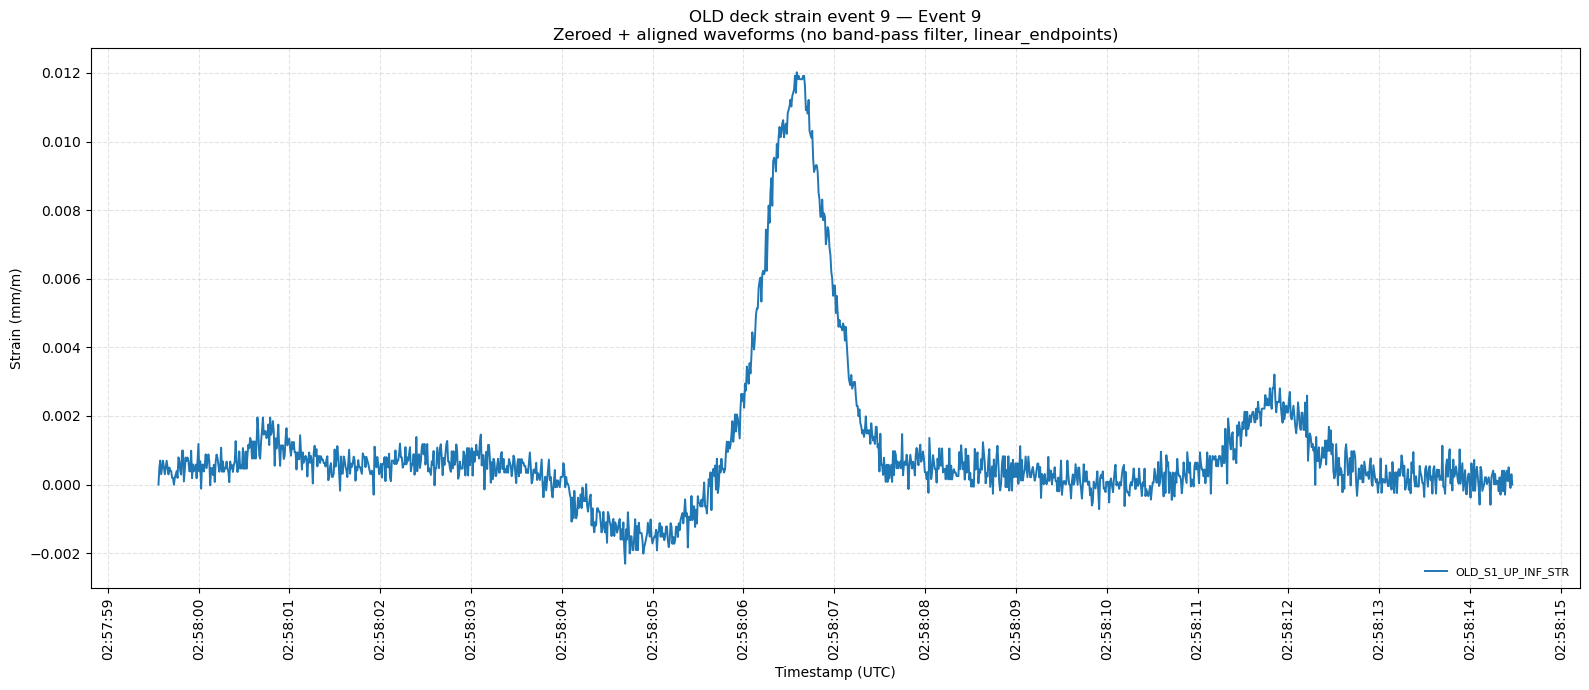

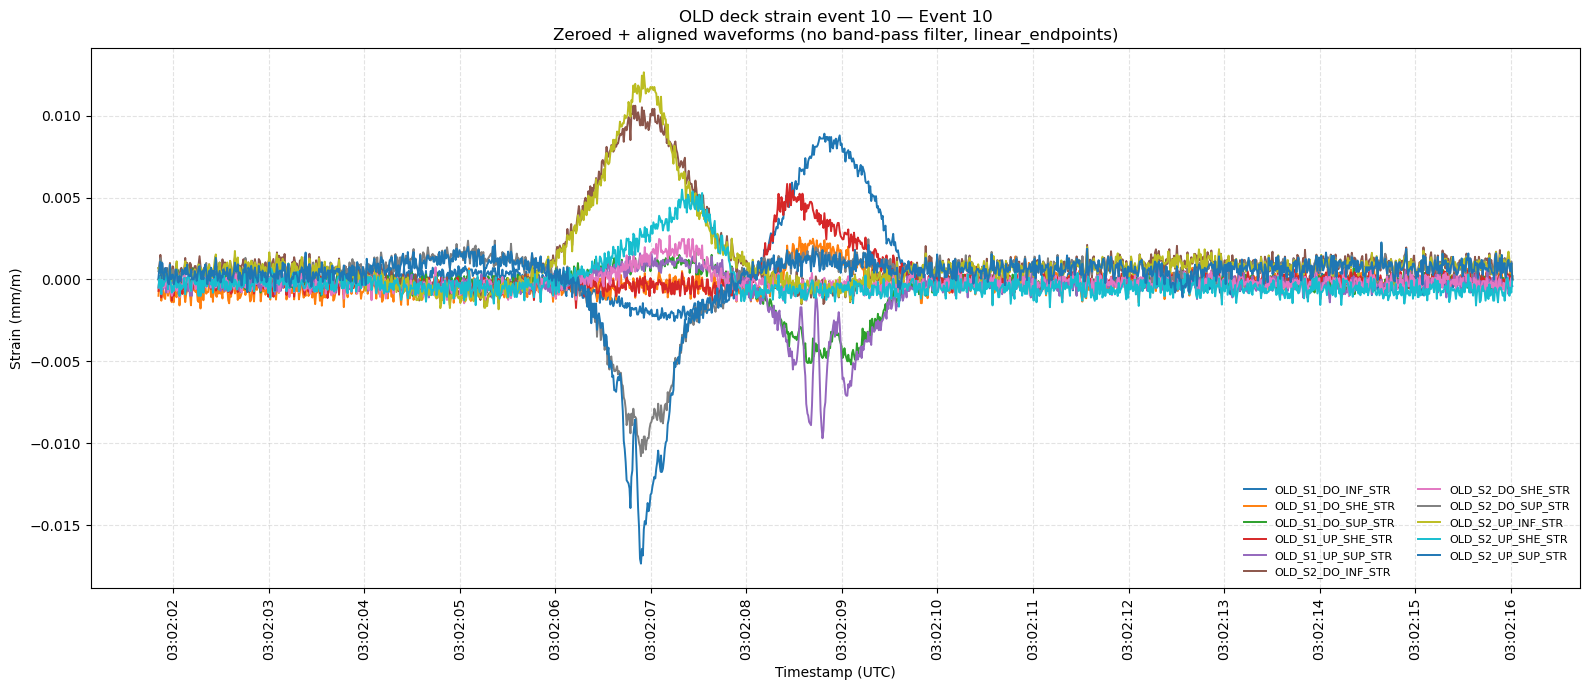

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

organizer_reader = AquinasReader(DATASET_ROOT / "AQUINAS_SET1_2022_07")

# Prendi tutti gli eventi OLD STR disponibili
organizer_events = find_events(
    organizer_reader,
    deck="OLD",
    sensor_pattern="STR",
)

if organizer_events.empty:
    raise ValueError("No OLD-deck strain events found in the dataset.")

# Ordina per tempo, se disponibile
if "timestamp_utc" in organizer_events.columns:
    organizer_events = organizer_events.sort_values("timestamp_utc")
elif "timestamp" in organizer_events.columns:
    organizer_events = organizer_events.sort_values("timestamp")

# Primi 10 eventi
events_to_plot = organizer_events.head(10)

for idx, (_, organizer_event) in enumerate(events_to_plot.iterrows(), start=1):
    # Load -> zero -> align
    loaded = load_event_group(organizer_reader, organizer_event)
    zeroed = zero_loaded_event_group(loaded)
    aligned = align_event_group(zeroed)

    frame = aligned.aligned_waveform
    sensor_columns = [c for c in frame.columns if c != "timestamp_utc"]

    fig, ax = plt.subplots(figsize=(16, 7))

    for sensor in sensor_columns:
        ax.plot(
            frame["timestamp_utc"],
            frame[sensor],
            linewidth=1.4,
            label=sensor,
        )

    # Titolo evento
    event_time = None
    if "timestamp_utc" in organizer_event.index:
        event_time = organizer_event["timestamp_utc"]
    elif "timestamp" in organizer_event.index:
        event_time = organizer_event["timestamp"]

    title_time = str(event_time) if event_time is not None else f"Event {idx}"

    ax.set_title(
        f"OLD deck strain event {idx} — {title_time}\n"
        f"Zeroed + aligned waveforms (no band-pass filter, {aligned.zeroing_method})"
    )
    ax.set_xlabel("Timestamp (UTC)")
    ax.set_ylabel("Strain (mm/m)")
    ax.grid(True, linestyle="--", alpha=0.35)

    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    plt.setp(ax.get_xticklabels(), rotation=90, ha="center")

    ax.legend(loc="lower right", fontsize=8, ncol=2, frameon=False)
    plt.tight_layout()
    plt.show()

    # opzionale: chiude la figura per evitare accumulo di memoria
    plt.close(fig)

This cell processes each event, keeping for each sensor the average value of the absolute value of the strain time history (to avoid that positive strain compensate negative ones) and save events in a .csv file. You can run and stop, and then resume from the last strain processed.


In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_CSV = "sensor_mean_abs_per_event.csv"

organizer_reader = AquinasReader(DATASET_ROOT / "AQUINAS_SET1_2022_07")

organizer_events = find_events(
    organizer_reader,
    deck="OLD",
    sensor_pattern="STR",
)

if organizer_events.empty:
    raise ValueError("No OLD-deck strain events found in the dataset.")

# -----------------------------
# Filtra eventi da 12 sensori
# -----------------------------
events = organizer_events.copy()
events["start_time_utc"] = pd.to_datetime(events["start_time_utc"], errors="coerce")
events_12 = events[events["active_sensor_count"] == 12].copy()
events_12 = events_12.sort_values("start_time_utc").reset_index(drop=True)

if events_12.empty:
    raise ValueError("No events with exactly 12 sensors found.")

# -----------------------------
# Resume: carica eventi già processati
# -----------------------------
if os.path.exists(OUTPUT_CSV):
    existing_df = pd.read_csv(OUTPUT_CSV)
    processed_event_ids = set(existing_df["event_id"].astype(str))
    print(f"🔁 Resume mode: {len(processed_event_ids)} events already processed")
else:
    existing_df = pd.DataFrame()
    processed_event_ids = set()

# -----------------------------
# Loop eventi
# -----------------------------
for idx, (_, organizer_event) in enumerate(events_12.iterrows(), start=1):

    event_id = str(organizer_event["event_id"])

    if event_id in processed_event_ids:
        continue  # skip già fatto

    print(f"Processing event {idx}/{len(events_12)} (ID={event_id})")

    try:
        loaded = load_event_group(organizer_reader, organizer_event)
        zeroed = zero_loaded_event_group(loaded)
        aligned = align_event_group(zeroed)

        frame = aligned.aligned_waveform
        sensor_columns = [c for c in frame.columns if c != "timestamp_utc"]

        if len(sensor_columns) != 12:
            print(f"⚠️ Skipping event {event_id}: found {len(sensor_columns)} sensors")
            continue

        # -----------------------------
        # MEAN OF ABS VALUE
        # -----------------------------
        abs_means = frame[sensor_columns].abs().mean(axis=0, skipna=True)

        rows = []
        for sensor in sensor_columns:
            rows.append({
                "event_id": event_id,
                "start_time_utc": organizer_event["start_time_utc"],
                "sensor": sensor,
                "mean_abs_value": abs_means[sensor],
            })

        out_df = pd.DataFrame(rows)

        # -----------------------------
        # Scrittura incrementale
        # -----------------------------
        if not os.path.exists(OUTPUT_CSV):
            out_df.to_csv(OUTPUT_CSV, index=False, mode="w")
        else:
            out_df.to_csv(OUTPUT_CSV, index=False, mode="a", header=False)

    except Exception as e:
        print(f"❌ Error on event {event_id}: {e}")
        continue

print("✅ Processing completed (or safely interrupted).")

🔁 Resume mode: 298 events already processed
Processing event 299/1352 (ID=AQUINAS_SET1_2022_07__OLD__2022-07-06T13-02-40Z__2022-07-06T13-02-52Z)
Processing event 300/1352 (ID=AQUINAS_SET1_2022_07__OLD__2022-07-06T13-06-17Z__2022-07-06T13-06-29Z)
Processing event 301/1352 (ID=AQUINAS_SET1_2022_07__OLD__2022-07-06T13-26-20Z__2022-07-06T13-26-33Z)
Processing event 302/1352 (ID=AQUINAS_SET1_2022_07__OLD__2022-07-06T13-36-37Z__2022-07-06T13-36-49Z)
Processing event 303/1352 (ID=AQUINAS_SET1_2022_07__OLD__2022-07-06T13-49-39Z__2022-07-06T13-49-51Z)
Processing event 304/1352 (ID=AQUINAS_SET1_2022_07__OLD__2022-07-06T14-11-34Z__2022-07-06T14-11-47Z)
Processing event 305/1352 (ID=AQUINAS_SET1_2022_07__OLD__2022-07-06T14-17-40Z__2022-07-06T14-17-53Z)
Processing event 306/1352 (ID=AQUINAS_SET1_2022_07__OLD__2022-07-06T14-31-55Z__2022-07-06T14-32-10Z)
Processing event 307/1352 (ID=AQUINAS_SET1_2022_07__OLD__2022-07-06T15-31-28Z__2022-07-06T15-31-40Z)
Processing event 308/1352 (ID=AQUINAS_SET1_2022

KeyboardInterrupt: 

This cell prints the ratio between the two quantities. The ratio is more or less constant and not dependent on temeprature. Discussion should be made on outliers.


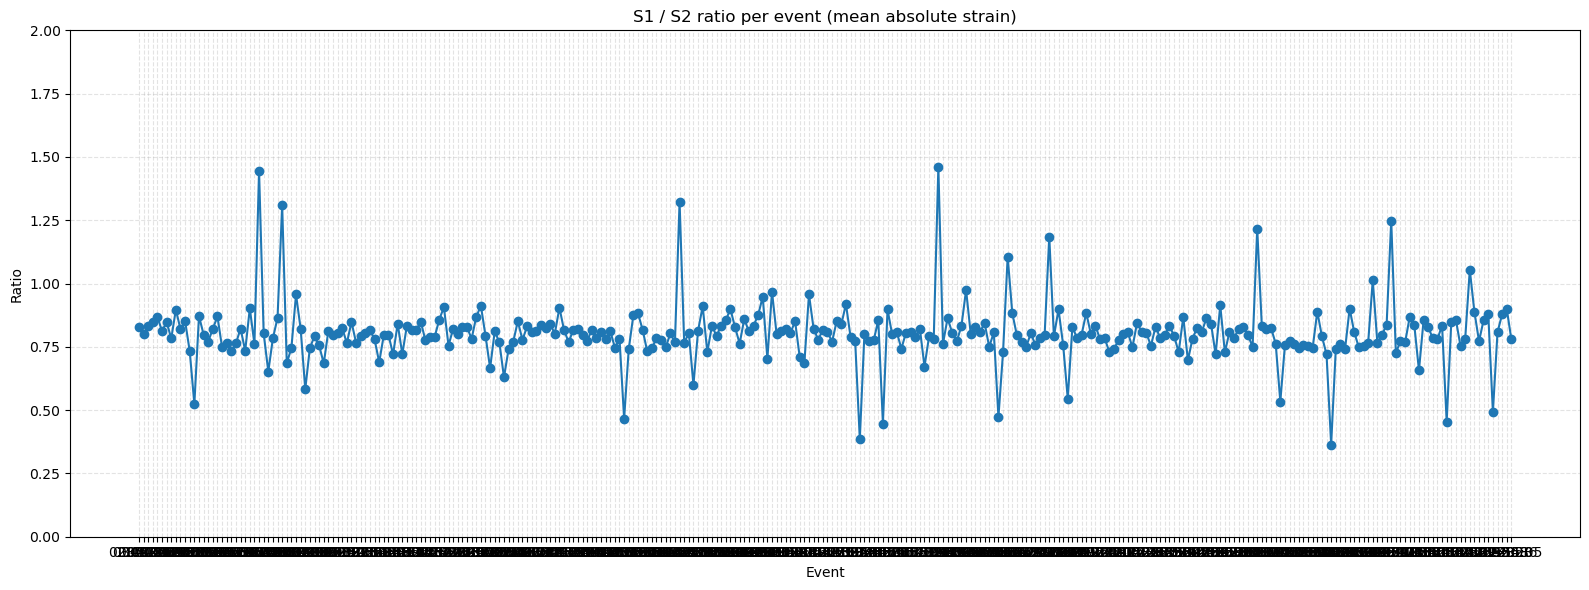

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Carica CSV
# -----------------------------
INPUT_CSV = "sensor_mean_abs_per_event.csv"
df = pd.read_csv(INPUT_CSV)

df["start_time_utc"] = pd.to_datetime(df["start_time_utc"], errors="coerce")

# -----------------------------
# Ordina eventi
# -----------------------------
event_order = (
    df[["event_id", "start_time_utc"]]
    .drop_duplicates()
    .sort_values("start_time_utc")
    .reset_index(drop=True)
)

event_order["event_idx"] = range(1, len(event_order) + 1)
df = df.merge(event_order, on=["event_id", "start_time_utc"], how="left")

# -----------------------------
# Classificazione automatica S1 / S2
# -----------------------------
df["group"] = df["sensor"].apply(
    lambda s: "S1" if "_S1_" in s else ("S2" if "_S2_" in s else None)
)

# opzionale: check
if df["group"].isna().any():
    print("⚠️ Alcuni sensori non classificati:", df[df["group"].isna()]["sensor"].unique())

# -----------------------------
# Calcolo rapporto per evento
# -----------------------------
results = []

for event_id, g in df.groupby("event_id"):

    sum_s1 = g[g["group"] == "S1"]["mean_abs_value"].sum()
    sum_s2 = g[g["group"] == "S2"]["mean_abs_value"].sum()

    if sum_s2 == 0:
        ratio = None
    else:
        ratio = sum_s1 / sum_s2

    results.append({
        "event_id": event_id,
        "event_idx": g["event_idx"].iloc[0],
        "start_time_utc": g["start_time_utc"].iloc[0],
        "ratio": ratio,
    })

ratio_df = pd.DataFrame(results).sort_values("event_idx")

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    ratio_df["event_idx"],
    ratio_df["ratio"],
    marker="o",
    linewidth=1.5,
)

ax.set_title("S1 / S2 ratio per event (mean absolute strain)")
ax.set_xlabel("Event")
ax.set_ylabel("Ratio")

# limite asse y
ax.set_ylim(0, 2)

ax.grid(True, linestyle="--", alpha=0.35)

# etichette eventi
labels = ratio_df["start_time_utc"].dt.strftime("%H:%M:%S")
ax.set_xticks(ratio_df["event_idx"])
ax.set_xticklabels(labels)

plt.tight_layout()
plt.show()